## Parte 02 - Auditoria do Modelo em Produção

Como a base apresenta desbalanceamento relevante entre categorias, a acurácia global foi reportada apenas como métrica descritiva inicial. Para avaliar o desempenho de forma mais robusta, foram priorizadas métricas macro, como F1 macro, recall macro e acurácia balanceada, pois elas atribuem peso semelhante às categorias, evitando que classes majoritárias dominem a avaliação.

#### Imports, Configuração e Leitura dos Dados

In [34]:
import re
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import unicodedata
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    confusion_matrix
)

from IPython.display import display
from functions import pretty_label, save_figure, save_table, load_and_prepare_data
warnings.filterwarnings("ignore")

In [35]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

output_dir = Path("../results")
fig_dir = output_dir / "figures/auditoria_modelo_a"
tab_dir = output_dir / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
tab_dir.mkdir(parents=True, exist_ok=True)

In [36]:
path = Path("../dados/chamados_com_predicoes.csv")
df = load_and_prepare_data(path)

n_bootstrap = 1000
seed = 42
alpha = 0.05

In [38]:
df["pred_modelo_a"] = df["pred_modelo_a"].astype(str).str.strip()
df["acerto_modelo_a"] = df["pred_modelo_a"].eq(df["categoria_real"])
df["erro_modelo_a"] = ~df["acerto_modelo_a"]
df["log_palavras"] = np.log1p(df["palavra_count"])
df["faixa_tamanho_texto"] = pd.qcut(
    df["palavra_count"],q=4,
    labels=["Textos mais curtos",
            "Textos médio-curtos",
            "Textos médio-longos",
            "Textos mais longos"],
    duplicates="drop")

df["faixa_confianca_a"] = pd.cut(df["conf_modelo_a"],bins=np.linspace(0, 1, 11),include_lowest=True)
classes = (df["categoria_real"].value_counts().sort_values(ascending=False).index.tolist())

### 1. Desempenho com Incertezas

#### 1.1 Desempenho Geral do Modelo com Bootstrapping

In [ ]:
def calcular_metricas_globais(y_true, y_pred, labels):
    return {
        "Acurácia": accuracy_score(y_true, y_pred),
        "Acurácia Balanceada": balanced_accuracy_score(y_true, y_pred),
        "Precisão Macro": precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
        "Precisão Ponderada": precision_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
        "Recall Ponderada": recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
        "F1 Ponderada": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
        "Kappa de Cohen": cohen_kappa_score(y_true, y_pred, labels=labels),
        "Coeficiente de Matthews": matthews_corrcoef(y_true, y_pred)
    }

def gerar_amostra_bootstrap_estratificada(df, coluna_estrato, rng):
    indices = []

    for _, grupo in df.groupby(coluna_estrato):
        idx = grupo.index.to_numpy()
        idx_boot = rng.choice(idx, size=len(idx), replace=True)
        indices.append(idx_boot)

    indices = np.concatenate(indices)

    return df.loc[indices].copy()

def bootstrap_metricas_globais(df, coluna_real="categoria_real", coluna_pred="pred_modelo_a", coluna_estrato="categoria_real",
    labels=None, n_bootstrap=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    metricas_ponto = calcular_metricas_globais(
        df[coluna_real],
        df[coluna_pred],
        labels
    )

    resultados_boot = []
    for _ in range(n_bootstrap):
        amostra = gerar_amostra_bootstrap_estratificada(df, coluna_estrato=coluna_estrato, rng=rng)
        metricas_boot = calcular_metricas_globais(amostra[coluna_real], amostra[coluna_pred], labels)
        resultados_boot.append(metricas_boot)
        
    boot = pd.DataFrame(resultados_boot)
    tabela = []

    for metrica, valor in metricas_ponto.items():
        tabela.append({
            "Métrica": metrica,
            "Estimativa": valor,
            "IC Inf. (95%)": boot[metrica].quantile(alpha / 2),
            "IC Sup. (95%)": boot[metrica].quantile(1 - alpha / 2),
            "Desvio Bootstrap": boot[metrica].std()})

    return pd.DataFrame(tabela), boot

In [ ]:
tabela_metricas_globais_a, bootstrap_global_a = bootstrap_metricas_globais(
    df, labels=classes, n_bootstrap=n_bootstrap, alpha=alpha, seed=seed)

display(tabela_metricas_globais_a)
save_table(tabela_metricas_globais_a, tab_dir,"05_metricas_globais_modelo_a_com_ic")

,Métrica,Estimativa,IC Inf. (95%),IC Sup. (95%),Desvio Bootstrap
0,Acurácia,0.772800,0.761585,0.784205,0.005741
1,Acurácia Balanceada,0.770992,0.757232,0.784578,0.006556
2,Precisão Macro,0.774338,0.762293,0.786914,0.006309
3,Recall Macro,0.770992,0.757232,0.784578,0.006556
4,F1 Macro,0.770438,0.757629,0.782721,0.006217
5,Precisão Ponderada,0.777637,0.766532,0.789403,0.005707
6,Recall Ponderada,0.772800,0.761585,0.784205,0.005741
7,F1 Ponderada,0.772524,0.761260,0.784059,0.005759
8,Kappa de Cohen,0.732224,0.718749,0.745707,0.006772
9,Coeficiente de Matthews,0.733362,0.719765,0.746989,0.006744


PosixPath('../results/tables/05_metricas_globais_modelo_a_com_ic.csv')

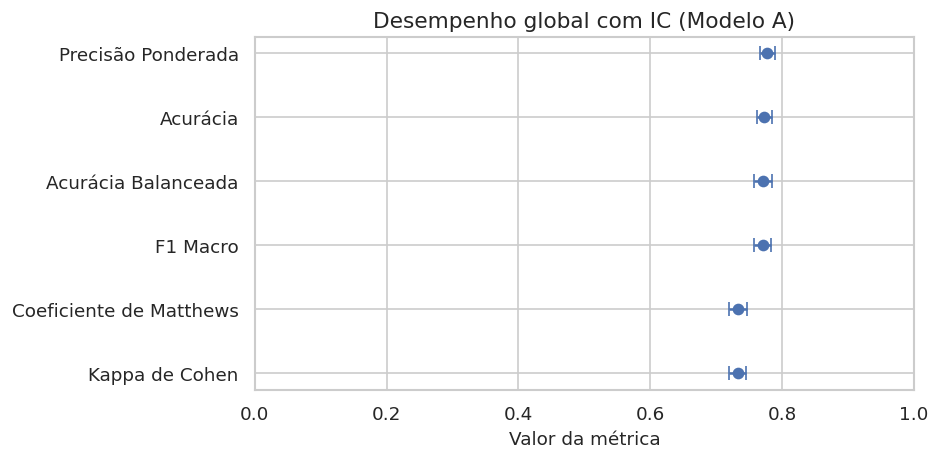

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
metricas_plot = tabela_metricas_globais_a[
    tabela_metricas_globais_a["Métrica"].isin(["Acurácia", "Acurácia Balanceada",
    "F1 Macro", "Precisão Ponderada","Kappa de Cohen","Coeficiente de Matthews"])].copy()

metricas_plot = metricas_plot.sort_values("Estimativa")
ax.errorbar(metricas_plot["Estimativa"], metricas_plot["Métrica"],
    xerr=[metricas_plot["Estimativa"] - metricas_plot["IC Inf. (95%)"], metricas_plot["IC Sup. (95%)"] - metricas_plot["Estimativa"]],
    fmt="o", capsize=4)

ax.set_title("Desempenho global com IC (Modelo A)")
ax.set_xlabel("Valor da métrica")
ax.set_ylabel("")
ax.set_xlim(0, 1)
save_figure(fig, fig_dir,"05_metricas_globais_modelo_a_ic.png")
plt.show()

#### 1.2 Desempenho Estratificado por Categoria

In [ ]:
def intervalo_wilson(sucessos, n, alpha=0.05):
    if n == 0: return np.nan, np.nan
    inferior, superior = proportion_confint(count=sucessos, nobs=n, alpha=alpha, method="wilson")
    return inferior, superior

def calcular_metricas_por_categoria(df, labels, alpha=0.05):
    total_erros = df["erro_modelo_a"].sum()
    linhas = []

    for classe in labels:
        real = df["categoria_real"].eq(classe)
        pred = df["pred_modelo_a"].eq(classe)
        tp, fp, fn, tn = ((real & pred).sum(), (~real & pred).sum(),
                        (real & ~pred).sum(), (~real & ~pred).sum())

        sup_real, sup_pred = real.sum(), pred.sum()
        precisao = tp / sup_pred if sup_pred else np.nan
        recall = tp / sup_real if sup_real else np.nan
        f1 = 2 * precisao * recall / (precisao + recall) if precisao + recall > 0 else np.nan
        taxa_erro = fn / sup_real if sup_real else np.nan

        p_ic = intervalo_wilson(tp, sup_pred, alpha)
        r_ic = intervalo_wilson(tp, sup_real, alpha)
        e_ic = intervalo_wilson(fn, sup_real, alpha)

        linhas.append({
            "categoria": classe,
            "suporte_real": sup_real,
            "suporte_predito": sup_pred,
            "precisao": precisao,
            "precisao_ic95_inf": p_ic[0],
            "precisao_ic95_sup": p_ic[1],
            "recall": recall,
            "recall_ic95_inf": r_ic[0],
            "recall_ic95_sup": r_ic[1],
            "f1": f1,
            "taxa_erro": taxa_erro,
            "taxa_erro_ic95_inf": e_ic[0],
            "taxa_erro_ic95_sup": e_ic[1],
            "participacao_erros_totais": fn / total_erros if total_erros else np.nan
        })

    return pd.DataFrame(linhas)

def bootstrap_f1_por_categoria(df, labels, n_bootstrap=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    linhas = []

    for _ in range(n_bootstrap):
        amostra = gerar_amostra_bootstrap_estratificada(
            df, coluna_estrato="categoria_real", rng=rng)

        for classe in labels:
            y_true_bin = amostra["categoria_real"] == classe
            y_pred_bin = amostra["pred_modelo_a"] == classe

            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

            linhas.append({
                "categoria": classe,
                "f1_bootstrap": f1
            })

    boot = pd.DataFrame(linhas)

    ci = (boot.groupby("categoria")["f1_bootstrap"].agg(
            f1_ic95_inf=lambda x: x.quantile(alpha / 2),
            f1_ic95_sup=lambda x: x.quantile(1 - alpha / 2),
            f1_desvio_bootstrap="std").reset_index())
    return ci, boot

In [ ]:
tabela_categoria_a = calcular_metricas_por_categoria(df, labels=classes, alpha=alpha)
ic_f1_categoria_a, bootstrap_f1_categoria_a = bootstrap_f1_por_categoria(
    df, labels=classes, n_bootstrap=n_bootstrap, alpha=alpha, seed=seed)

tabela_categoria_a = tabela_categoria_a.merge(ic_f1_categoria_a, on="categoria", how="left")
tabela_categoria_a = tabela_categoria_a.sort_values("suporte_real", ascending=False)
display(tabela_categoria_a)
save_table(tabela_categoria_a, tab_dir, "05_metricas_por_categoria_modelo_a_com_ic")

,categoria,suporte_real,suporte_predito,precisao,precisao_ic95_inf,precisao_ic95_sup,recall,recall_ic95_inf,recall_ic95_sup,f1,taxa_erro,taxa_erro_ic95_inf,taxa_erro_ic95_sup,participacao_erros_totais,f1_ic95_inf,f1_ic95_sup,f1_desvio_bootstrap
0,iluminacao_publica,1143,1057,0.857143,0.834753,0.876946,0.792651,0.768187,0.815154,0.823636,0.207349,0.184846,0.231813,0.208627,0.807337,0.840397,0.008248
1,buraco_via,908,1117,0.664279,0.636064,0.691369,0.817181,0.790721,0.840968,0.732840,0.182819,0.159032,0.209279,0.146127,0.714423,0.751357,0.009447
2,coleta_lixo,806,798,0.814536,0.786085,0.839974,0.806452,0.777749,0.832247,0.810474,0.193548,0.167753,0.222251,0.137324,0.789886,0.831368,0.010242
3,esgoto_vazamento,621,504,0.712302,0.671291,0.750100,0.578100,0.538894,0.616346,0.638222,0.421900,0.383654,0.461106,0.230634,0.605726,0.671259,0.016312
4,poda_arvore,458,442,0.803167,0.763556,0.837555,0.775109,0.734675,0.810967,0.788889,0.224891,0.189033,0.265325,0.090669,0.759686,0.817978,0.014543
5,estacionamento_irregular,437,451,0.800443,0.761089,0.834723,0.826087,0.787749,0.858742,0.813063,0.173913,0.141258,0.212251,0.066901,0.784350,0.838786,0.014087
6,barulho_perturbacao,400,387,0.801034,0.758386,0.837764,0.775000,0.731573,0.813195,0.787802,0.225000,0.186805,0.268427,0.079225,0.757106,0.817259,0.015127
7,sinalizacao,227,244,0.741803,0.683441,0.792670,0.797357,0.740319,0.844498,0.768577,0.202643,0.155502,0.259681,0.040493,0.729158,0.809345,0.020636


PosixPath('../results/tables/05_metricas_por_categoria_modelo_a_com_ic.csv')

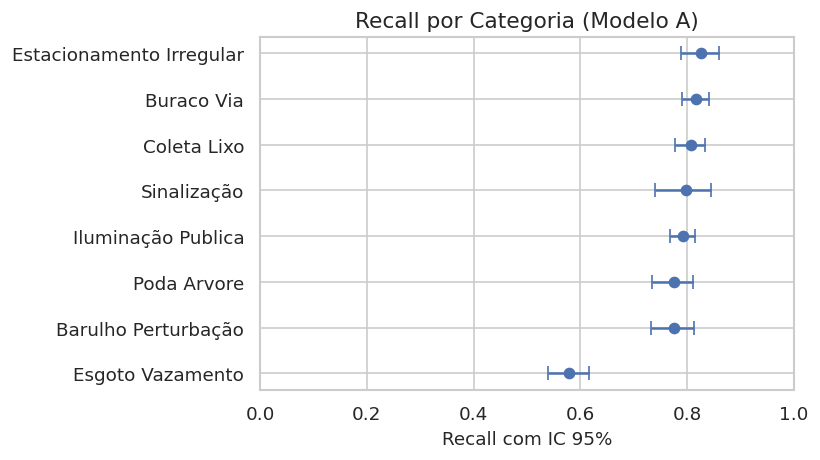

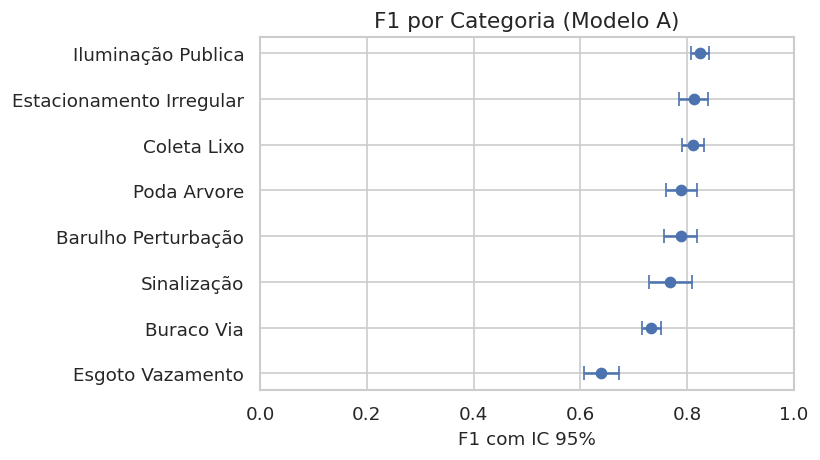

In [57]:
def plotar_metrica_categoria(tabela, metrica, titulo, xlabel, nome_arquivo):
    dados = tabela.sort_values(metrica)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.errorbar(dados[metrica], dados["categoria"].map(pretty_label),
        xerr=[dados[metrica] - dados[f"{metrica}_ic95_inf"], dados[f"{metrica}_ic95_sup"] - dados[metrica]],
        fmt="o",capsize=4)

    ax.set(title=titulo, xlabel=xlabel, ylabel="", xlim=(0, 1))
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()

plotar_metrica_categoria(
    tabela_categoria_a, "recall",
    "Recall por Categoria (Modelo A)","Recall com IC 95%", "05_recall_por_categoria_modelo_a_ic.png")

plotar_metrica_categoria(
    tabela_categoria_a, "f1",
    "F1 por Categoria (Modelo A)", "F1 com IC 95%", "05_f1_por_categoria_modelo_a_ic.png")

#### 1.3 Análise da Confiança do Modelo (Acertos e Erros)

In [51]:
def tabela_calibracao(df, coluna_conf="conf_modelo_a", coluna_acerto="acerto_modelo_a"):
    tabela = (df.groupby("faixa_confianca_a").agg(
            n=("id_chamado", "count"),
            confianca_media=(coluna_conf, "mean"),
            acuracia_observada=(coluna_acerto, "mean")).reset_index())

    tabela["gap_calibracao"] = tabela["confianca_media"] - tabela["acuracia_observada"]
    tabela["peso"] = tabela["n"] / tabela["n"].sum()

    ece = (tabela["peso"] * tabela["gap_calibracao"].abs()).sum()
    return tabela, ece

,acerto_modelo_a,n,confianca_media,confianca_mediana,confianca_p10,confianca_p90,resultado
0,False,1136,0.922631,0.935,0.851,0.976,Erros
1,True,3864,0.922826,0.933,0.854,0.979,Acertos


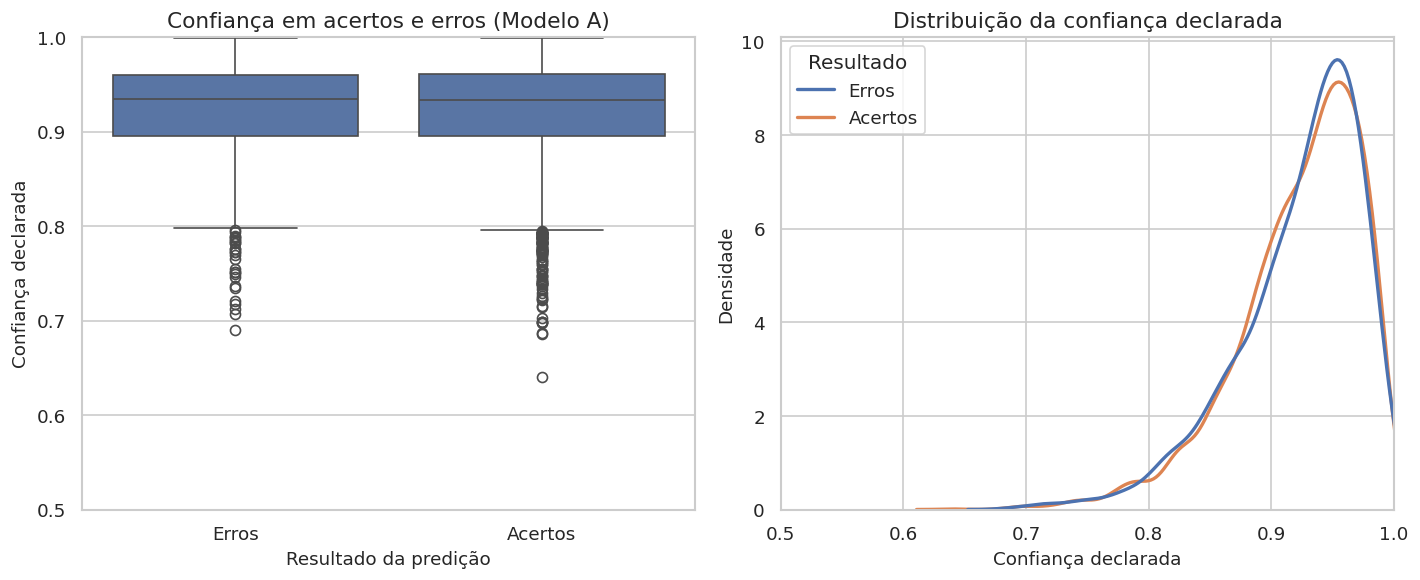

In [52]:
tabela_confianca_acerto = (
    df.groupby("acerto_modelo_a")
    .agg(
        n=("id_chamado", "count"),
        confianca_media=("conf_modelo_a", "mean"),
        confianca_mediana=("conf_modelo_a", "median"),
        confianca_p10=("conf_modelo_a", lambda x: x.quantile(0.10)),
        confianca_p90=("conf_modelo_a", lambda x: x.quantile(0.90))
    )
    .reset_index()
)

tabela_confianca_acerto["resultado"] = tabela_confianca_acerto["acerto_modelo_a"].map({
    True: "Acertos",
    False: "Erros"
})

display(tabela_confianca_acerto)
save_table(tabela_confianca_acerto, tab_dir, "06_confianca_por_acerto_erro_modelo_a.csv")

df_confianca_plot = df.copy()
df_confianca_plot["Resultado"] = df_confianca_plot["acerto_modelo_a"].map({
    True: "Acertos",
    False: "Erros"
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df_confianca_plot,
    x="Resultado",
    y="conf_modelo_a",
    order=["Erros", "Acertos"],
    ax=axes[0]
)

axes[0].set_title("Confiança em acertos e erros (Modelo A)")
axes[0].set_xlabel("Resultado da predição")
axes[0].set_ylabel("Confiança declarada")
axes[0].set_ylim(0.5, 1)

sns.kdeplot(
    data=df_confianca_plot,
    x="conf_modelo_a",
    hue="Resultado",
    hue_order=["Erros", "Acertos"],
    common_norm=False,
    fill=False,
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title("Distribuição da confiança declarada")
axes[1].set_xlabel("Confiança declarada")
axes[1].set_ylabel("Densidade")
axes[1].set_xlim(0.5, 1)

fig.tight_layout()
save_figure(fig, fig_dir, "06_confianca_acertos_erros_modelo_a.png")
plt.show()

In [53]:
tabela_calibracao_a, ece_a = tabela_calibracao(df)
print(f"Erro esperado de calibração aproximado (ECE): {ece_a:.4f}")

Erro esperado de calibração aproximado (ECE): 0.1517


#### 1.4 Curva de Calibração Aproximada

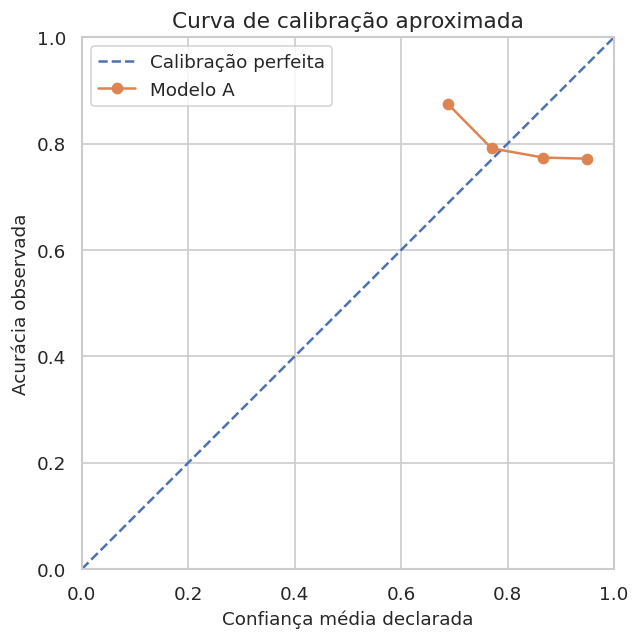

In [54]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], linestyle="--", label="Calibração perfeita")
ax.plot(tabela_calibracao_a["confianca_media"], tabela_calibracao_a["acuracia_observada"],
        marker="o", label="Modelo A")

ax.set_title("Curva de calibração aproximada")
ax.set_xlabel("Confiança média declarada")
ax.set_ylabel("Acurácia observada")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

save_figure(fig, fig_dir, "06_curva_calibracao_modelo_a.png")
plt.show()

### 2. Onde o Modelo Falha?

#### 2.1 Matriz de Confusão

In [ ]:
def matriz_confusao_tabelas(df, labels):
    matriz_abs = pd.DataFrame(confusion_matrix(df["categoria_real"], df["pred_modelo_a"], labels=labels),
        index=labels, columns=labels)

    matriz_pct_linha = matriz_abs.div(matriz_abs.sum(axis=1).replace(0, np.nan),axis=0) * 100
    return matriz_abs, matriz_pct_linha

def plotar_matriz_confusao(matriz_abs, matriz_pct, nome_arquivo):
    matriz_abs_plot = matriz_abs.copy()
    matriz_pct_plot = matriz_pct.copy()

    matriz_abs_plot.index = [pretty_label(x) for x in matriz_abs_plot.index]
    matriz_abs_plot.columns = [pretty_label(x) for x in matriz_abs_plot.columns]
    matriz_pct_plot.index = matriz_abs_plot.index
    matriz_pct_plot.columns = matriz_abs_plot.columns

    fig, ax = plt.subplots(figsize=(8,7))
    sns.heatmap(matriz_pct_plot, cmap="Blues", linewidths=0.5, cbar=True,
                annot=False, ax=ax, vmin=0, vmax=100)

    for i in range(matriz_abs_plot.shape[0]):
        for j in range(matriz_abs_plot.shape[1]):
            valor_abs = matriz_abs_plot.iloc[i, j]
            valor_pct = matriz_pct_plot.iloc[i, j]

            cor = "white" if valor_pct >= 50 else "#222222"
            ax.text(j + 0.5, i + 0.42, f"{valor_abs:.0f}",
                    ha="center", va="center", fontsize=10, color=cor)
            ax.text(j + 0.5, i + 0.65, f"({valor_pct:.1f}%)",
                    ha="center", va="center", fontsize=8, color=cor)

    ax.set_title("Matriz de confusão do Modelo A")
    ax.set_xlabel("Categoria prevista")
    ax.set_ylabel("Categoria real")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    fig.tight_layout()
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()

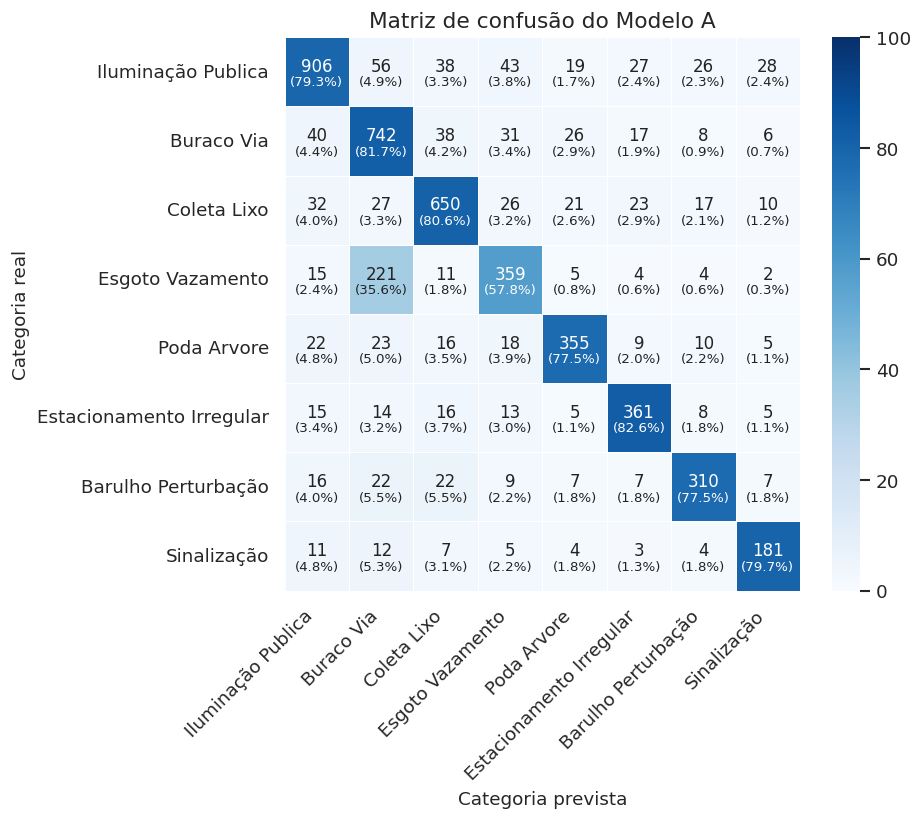

In [ ]:
matriz_abs_a, matriz_pct_a = matriz_confusao_tabelas(df, classes)
save_table(matriz_abs_a, tab_dir, "05_matriz_confusao_modelo_a_absoluta", index=True)
save_table(matriz_pct_a, tab_dir, "05_matriz_confusao_modelo_a_percentual_linha", index=True)

plotar_matriz_confusao(
    matriz_abs_a,
    matriz_pct_a,
    "05_matriz_confusao_modelo_a.png"
)

#### 2.3 Principais Erros 

In [ ]:
limiar_alta_confianca = 0.8
df_erros_alta_confianca = df[(df["erro_modelo_a"]) & (df["conf_modelo_a"] >= limiar_alta_confianca)].copy()

tabela_erros_alta_confianca = (
    df_erros_alta_confianca
    .groupby(["categoria_real", "pred_modelo_a"])
    .agg(n=("id_chamado", "count"),
        confianca_media=("conf_modelo_a", "mean"), confianca_mediana=("conf_modelo_a", "median")).reset_index().sort_values("n", ascending=False))

tabela_erros_alta_confianca["categoria_real_pt"] = tabela_erros_alta_confianca["categoria_real"].map(pretty_label)
tabela_erros_alta_confianca["categoria_prevista_pt"] = tabela_erros_alta_confianca["pred_modelo_a"].map(pretty_label)

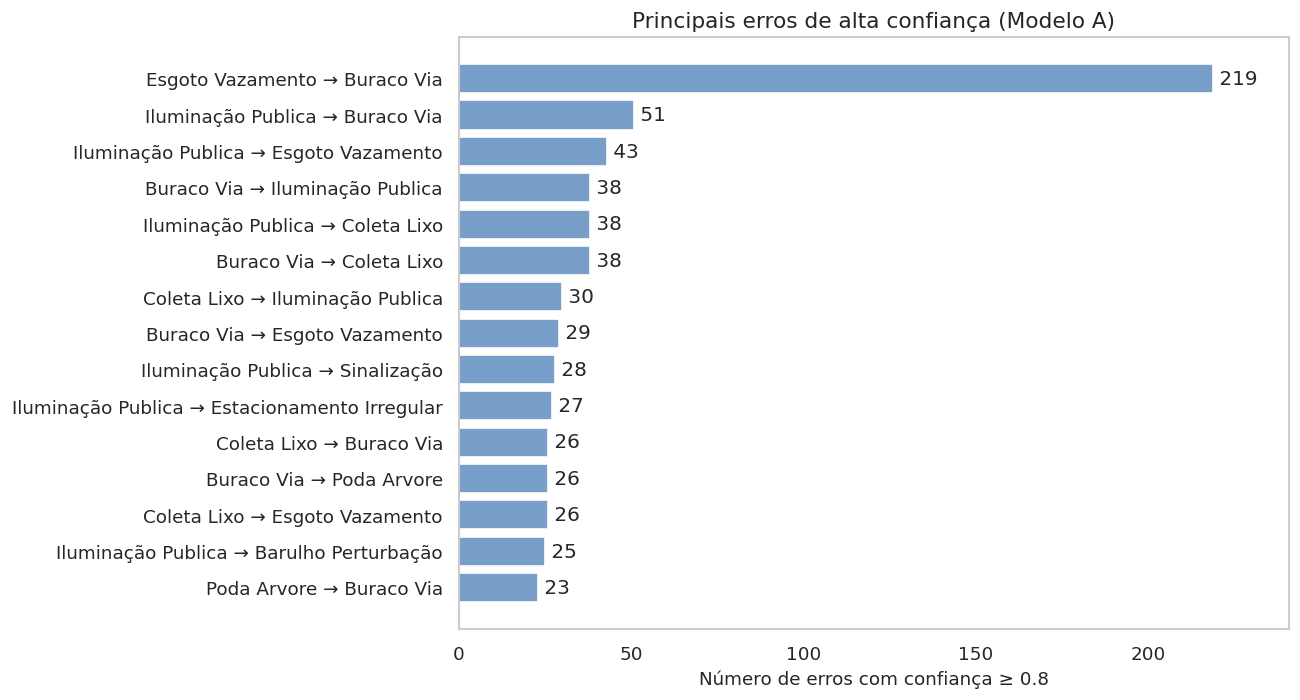

In [68]:
fig, ax = plt.subplots(figsize=(11, 6))
dados_plot = tabela_erros_alta_confianca.head(15).copy()
dados_plot["par_confusao"] = (dados_plot["categoria_real_pt"] + " → " + dados_plot["categoria_prevista_pt"])

dados_plot = dados_plot.sort_values("n", ascending=True)
valores = dados_plot["n"]
ax.grid(False)
ax.set_xlim(0, valores.max() * 1.1)
ax.barh(dados_plot["par_confusao"], valores,color="#779FC9")
ax.set_title("Principais erros de alta confiança (Modelo A)")
ax.set_xlabel(f"Número de erros com confiança ≥ {limiar_alta_confianca}")
ax.set_ylabel("")

for i, valor in enumerate(dados_plot["n"]):
    ax.text(valor, i, f" {valor}", va="center")

save_figure(fig, fig_dir, "06_principais_erros_alta_confianca_modelo_a.png")
plt.show()

#### 2.4 Testes de homogeneidade dos erros

In [ ]:
def teste_homogeneidade_erro(df, coluna):
    tabela = pd.crosstab(df[coluna], df["acerto_modelo_a"])

    if tabela.shape[0] < 2 or tabela.shape[1] < 2:
        return {"Variável": coluna,
                "Qui_Quadrado": np.nan,
                "P-Valor": np.nan,
                "Graus de Liberdade": np.nan,"n": len(df)}

    chi2, p, gl, _ = chi2_contingency(tabela)
    return {"Variável": coluna,
            "Qui-Quadrado": chi2,
            "P-Valor": p,
            "Graus de Liberdade": gl,"n": len(df)}

tabela_testes_homogeneidade = pd.DataFrame([
    teste_homogeneidade_erro(df, "categoria_real"),
    teste_homogeneidade_erro(df, "canal"),
    teste_homogeneidade_erro(df, "bairro"),
    teste_homogeneidade_erro(df, "faixa_tamanho_texto"),
    teste_homogeneidade_erro(df, "bool_texto_curto"),
    teste_homogeneidade_erro(df, "faixa_confianca_a")
])

display(tabela_testes_homogeneidade)
save_table(tabela_testes_homogeneidade, tab_dir, "06_testes_homogeneidade_erro_modelo_a.csv")

,Variável,Qui-Quadrado,P-Valor,Graus de Liberdade,n
0,categoria_real,159.896614,3.372557e-31,7,5000
1,canal,1.999563,3.679598e-01,2,5000
2,bairro,8.432123,8.656215e-01,14,5000
3,faixa_tamanho_texto,349.249771,2.168314e-75,3,5000
4,bool_texto_curto,11.288479,7.798956e-04,1,5000
5,faixa_confianca_a,0.765272,8.577541e-01,3,5000


PosixPath('../results/tables/06_testes_homogeneidade_erro_modelo_a.csv.csv')

#### 2.5 Investigando Fatores Associados ao Erro com Modelo Auxiliar

In [62]:
df_modelo_erro = df.copy()
df_modelo_erro["erro_int"] = df_modelo_erro["erro_modelo_a"].astype(int)

modelo_erro = smf.glm(formula="""
    erro_int ~ C(categoria_real) + C(canal) + C(faixa_tamanho_texto) + log_palavras""",
    data=df_modelo_erro,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

tabela_odds_erro = pd.DataFrame({
    "Variável": modelo_erro.params.index,
    "Coeficiente": modelo_erro.params.values,
    "Odds Ratio": np.exp(modelo_erro.params.values),
    "IC Inf. (95%)": np.exp(modelo_erro.conf_int()[0].values),
    "IC Sup. (95%)": np.exp(modelo_erro.conf_int()[1].values),
    "P-Valor": modelo_erro.pvalues.values
})

tabela_odds_erro = tabela_odds_erro[tabela_odds_erro["Variável"] != "Intercept"].sort_values("P-Valor")

display(tabela_odds_erro)
save_table(tabela_odds_erro, tab_dir, "06_regressao_logistica_fatores_associados_erro_modelo_a")

,Variável,Coeficiente,Odds Ratio,IC Inf. (95%),IC Sup. (95%),P-Valor
3,C(categoria_real)[T.esgoto_vazamento],1.053106,2.866540,2.109426,3.895396,1.695582e-11
10,C(faixa_tamanho_texto)[T.Textos médio-curtos],-0.974148,0.377514,0.153899,0.926043,3.335448e-02
11,C(faixa_tamanho_texto)[T.Textos médio-longos],-1.014998,0.362403,0.136176,0.964456,4.210981e-02
4,C(categoria_real)[T.estacionamento_irregular],-0.358806,0.698510,0.490592,0.994545,4.655745e-02
1,C(categoria_real)[T.buraco_via],-0.307145,0.735544,0.542550,0.997190,4.791861e-02
12,C(faixa_tamanho_texto)[T.Textos mais longos],-1.017886,0.361358,0.124784,1.046443,6.061630e-02
9,C(canal)[T.telefone_1746],-0.147930,0.862491,0.737422,1.008774,6.421557e-02
2,C(categoria_real)[T.coleta_lixo],-0.225777,0.797896,0.584871,1.088511,1.542254e-01
8,C(canal)[T.portal_web],-0.087208,0.916486,0.753241,1.115111,3.835653e-01
7,C(categoria_real)[T.sinalizacao],-0.185249,0.830897,0.545171,1.266373,3.889099e-01


PosixPath('../results/tables/06_regressao_logistica_fatores_associados_erro_modelo_a.csv')